# Lung Adenocarcinoma Survival Analytics

- This project analyzes clinical and gene expression data from The Cancer Genome Atlas (TCGA) to identify factors associated with 5-year survival in lung adenocarcinoma (LUAD) patients.
- The analysis includes cohort segmentation, biomarker evaluation, and survival outcome exploration to simulate real-world clinical analytics workflows.

## Dataset Overview

- Source: TCGA LUAD dataset via cBioPortal  
- Number of patients: 212  
- Features:
  - Clinical: age, gender, stage  
  - Outcome: 5-year survival (0:Survival, 1:Deceased)
  - Biomarkers: 30 gene expression features  

This dataset represents a cohort of lung cancer patients with associated genomic and clinical data.

## Data Validation

The dataset contains a balanced distribution of survival outcomes and minimal missing values. Age and stage information is partially missing, which is typical for clinical datasets and handled as "Unknown".

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('luad_analytics_dataset.csv')

df.head(5)

,patient_id,overall_survival_months,overall_survival_status,age,gender,stage,event,survival_5yr,AKT1,ALK,...,NRAS,PDCD1,PIK3CA,RB1,RET,ROS1,SMARCA4,STK11,TP53,VEGFA
0,TCGA-05-4250,3.978039,1:DECEASED,79.0,Female,Stage III,1,0,-1.0475,-0.8490,...,0.7879,1.7046,0.8062,0.8387,-0.7846,0.4237,-0.5742,-0.3183,-2.1890,1.0850
1,TCGA-05-4395,0.000000,1:DECEASED,76.0,Male,Stage III,1,0,-1.3604,-1.2188,...,1.4550,-0.1747,0.3443,-0.4809,-0.1480,-1.0888,-0.5807,0.5124,-0.0319,0.5732
2,TCGA-05-4396,9.961535,1:DECEASED,76.0,Male,Stage III,1,0,0.3895,-1.7834,...,2.6928,-1.0152,1.1727,1.4730,1.3009,0.6134,-0.1899,-3.5084,-2.3446,0.4621
3,TCGA-05-4397,24.032613,1:DECEASED,65.0,Male,Stage II,1,0,1.3291,3.0138,...,-0.0406,-0.6355,1.9261,-1.0100,0.4777,-0.6459,-0.3288,0.7419,-1.3342,-1.5368
4,TCGA-05-4402,8.021830,1:DECEASED,57.0,Female,Stage IV,1,0,1.3990,-0.6101,...,1.3335,-0.8319,0.6478,0.1487,-0.6852,0.4403,-0.1971,-0.2528,-2.0065,-0.2183


Introduction

In [3]:
df.shape


(212, 38)

In [4]:
df['survival_5yr'].value_counts()


survival_5yr
0    170
1     42
Name: count, dtype: int64

In [5]:
df.isna().sum()


patient_id                 0
overall_survival_months    0
overall_survival_status    0
age                        8
gender                     0
stage                      0
event                      0
survival_5yr               0
AKT1                       0
ALK                        0
ATM                        0
BRAF                       0
CCND1                      0
CD274                      0
CDKN2A                     0
CTLA4                      0
CXCL10                     0
CXCL9                      0
EGFR                       0
ERBB2                      0
KEAP1                      0
KRAS                       0
MAPK1                      0
MET                        0
MKI67                      0
MTOR                       0
MYC                        0
NF1                        0
NRAS                       0
PDCD1                      0
PIK3CA                     0
RB1                        0
RET                        0
ROS1                       0
SMARCA4       

In [6]:
df["stage"].value_counts()

stage
Stage I      93
Stage II     56
Stage III    48
Stage IV     15
Name: count, dtype: int64

Dataset contains 212 patients with balanced survival distribution and minimal missing values

## Clinical Analysis

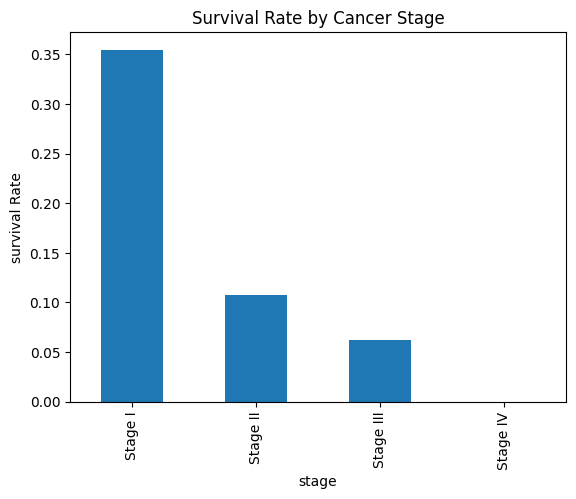

In [7]:
#Chart 1: Survival by Stage
stage_survival = df.groupby('stage')['survival_5yr'].mean()

stage_survival.plot(kind='bar')
plt.title("Survival Rate by Cancer Stage")
plt.ylabel("survival Rate")
plt.show()

Stage II, III and IV patients show significantly lower survival rates compared to Stage I, indicating strong association between disease progression and mortality risk. Stage I patients exhibit the highest survival rates, aligning with earlier detection and treatment effectiveness.

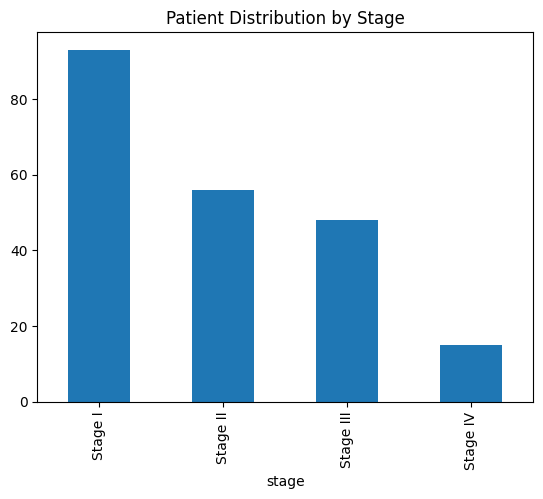

In [8]:
#Chart 2: Stage Distribution
df["stage"].value_counts().plot(kind="bar")
plt.title("Patient Distribution by Stage")
plt.show()

There are far more patient with stage I compared to other stages. Stage II and III patient distributions are about even. Stage IV patient disribution are significanly less compared to other patient stages. 


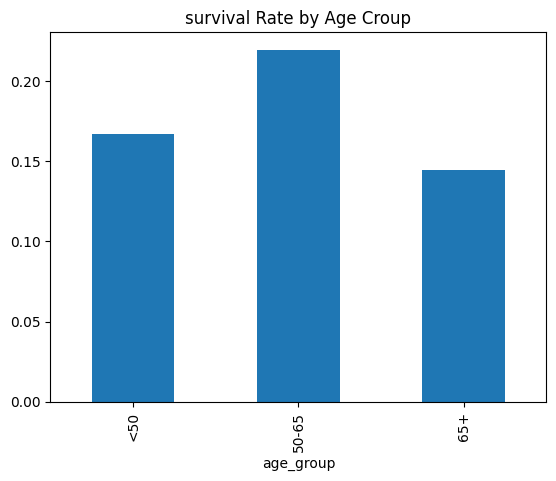

In [9]:
#Chart 3: Survival by Age Group
df['age_group'] = pd.cut(df['age'], bins=[0,50,65,100], labels = ['<50','50-65','65+'])

age_survival = df.groupby("age_group")['survival_5yr'].mean()

age_survival.plot(kind="bar")
plt.title("survival Rate by Age Croup")
plt.show()

Patients between the ages of 50-65 have a higher survival rate than patient younger than 50 and older than 65, yet overall survival is under 30%.

## Biomarker Analysis

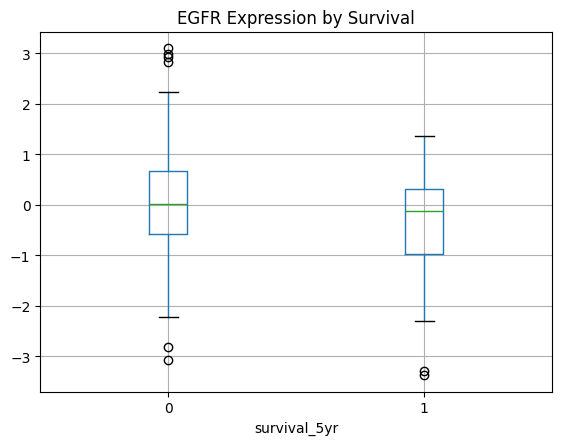

In [10]:
#Chart 4: EGFR Expression by Survival
df.boxplot(column="EGFR", by="survival_5yr")
plt.title("EGFR Expression by Survival")
plt.suptitle("")
plt.show()

Deceased patient had slightly lower expression levels for EGFR across the 5 metric points. Difference is minimal, but could allude to EGFR influence with mortality. 

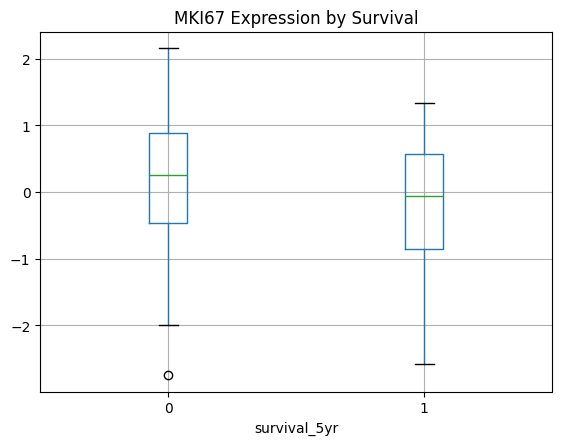

In [11]:
#Chart 5: MKI667 Proliferation Marker
df.boxplot(column="MKI67", by="survival_5yr")
plt.title("MKI67 Expression by Survival")
plt.suptitle("")
plt.show()

Higher expression appears associated with lower survival, suggesting increased tumor proliferation in high-risk patients. 

## Correlation analysis
- Gene expression features exhibit moderate correlation clusters, suggesting shared biological pathways and potential redundancy among biomarkers.

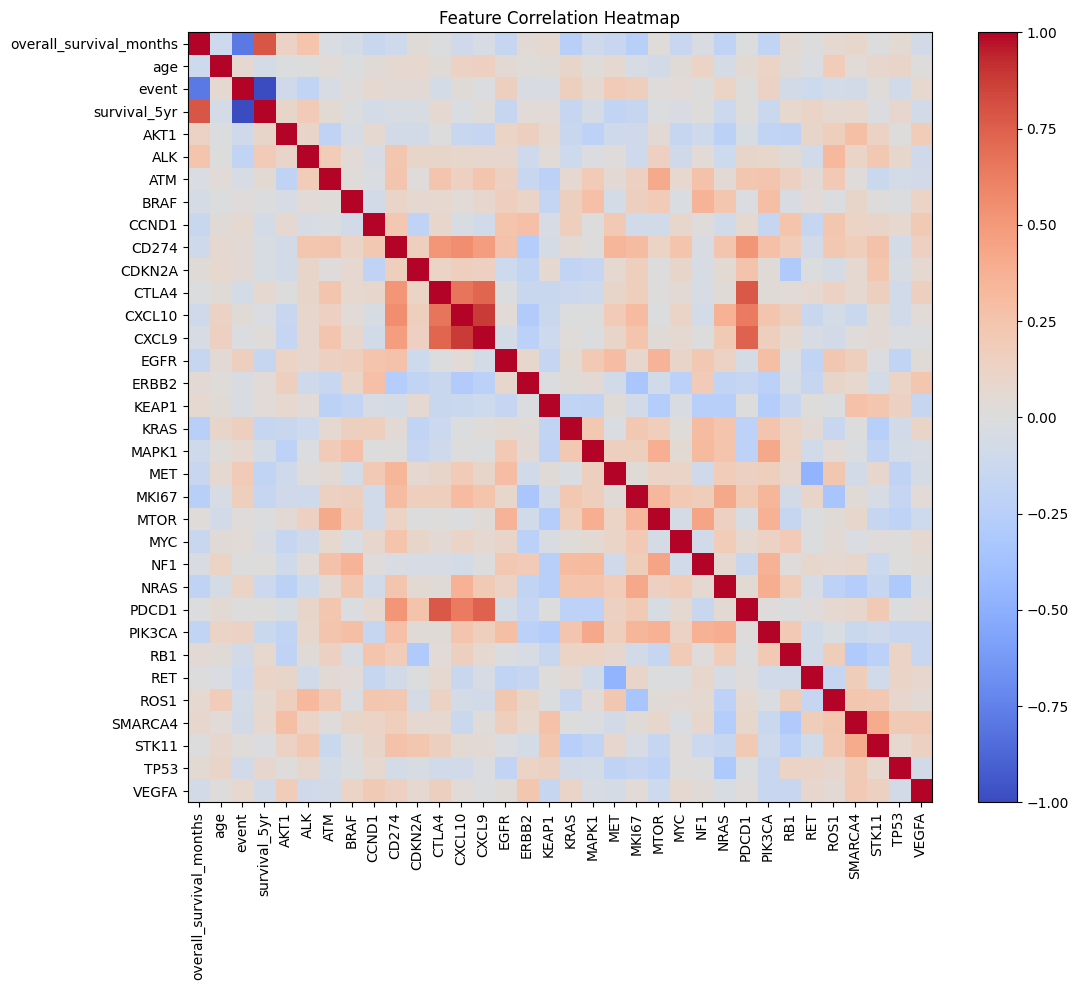

In [12]:
#Chart 6- Correlation Heatmap
import numpy as np
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 10))  # <-- makes plot larger

plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Heatmap")
plt.show()

Correlation analysis revealed strong positive correlation between overall survival months and 5-year survival, and strong negative correlation between event status and survival outcomes, as it was teh indicateor for evaluating 5 year survival. Immune-related genes including CXCL9, CXCL10, CTLA4, and PDCD1 showed correlated expression patterns, suggesting immune pathway activation. Proliferation-associated genes such as MKI67, MYC, and MTOR showed negative correlation with survival metrics, indicating that increased tumor proliferation may be associated with poorer survival outcomes.

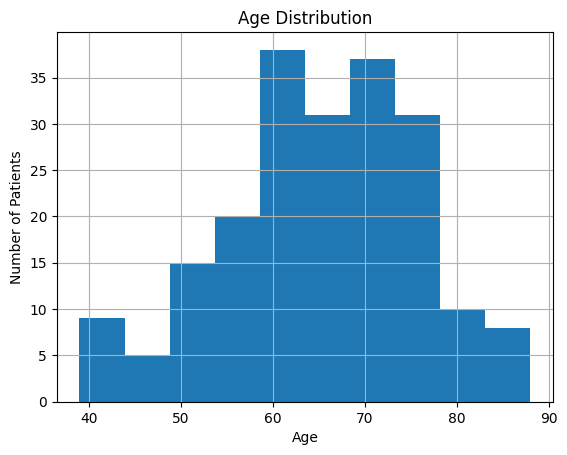

In [13]:
#Chart 7: Age Distribution
df["age"].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

The age distribution shows that most LUAD patients are between 60–75 years old, which is consistent with lung cancer being more prevalent in older populations.

Chart 8: Survival Distribution

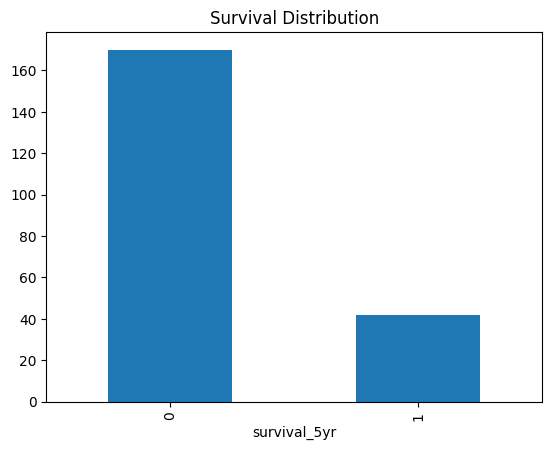

In [14]:
#Chart 8: Survival Distribution
df["survival_5yr"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.show()

The survival distribution is imbalanced, with more patients not surviving beyond 5 years. This  outcome distribution makes the dataset difficult for survival analysis and cohort comparisons.

## Key Findings

- Advanced tumor stage (Stage III/IV) is strongly associated with decreased 5-year survival  
- Older patients (65+) exhibit lower survival rates compared to younger cohorts  
- High MKI67 expression is associated with increased mortality risk, indicating higher tumor proliferation  
- Gene expression patterns show clustering, suggesting pathway-level interactions  
- Survival outcomes are relatively balanced, enabling reliable cohort analysis  

## Project Relevance

This analysis simulates real-world clinical analytics workflows used in precision medicine and oncology research. The findings demonstrate how patient stratification and biomarker analysis can support risk assessment and treatment decision-making.